In [1]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical calculations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for better data visualization
import seaborn as sns

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [2]:
# Load the heart disease dataset
df = pd.read_csv('heart.csv')

# Display first 5 rows
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [3]:
# Display number of rows and columns
print(df.shape)

# Display column names
print(df.columns)

# Display dataset information
df.info()

# Display summary statistics
print(df.describe())

(303, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
              age         sex          cp    trest

In [4]:
# Check missing values in each column
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
# Check target column values
print(df['target'].value_counts())

target
1    165
0    138
Name: count, dtype: int64


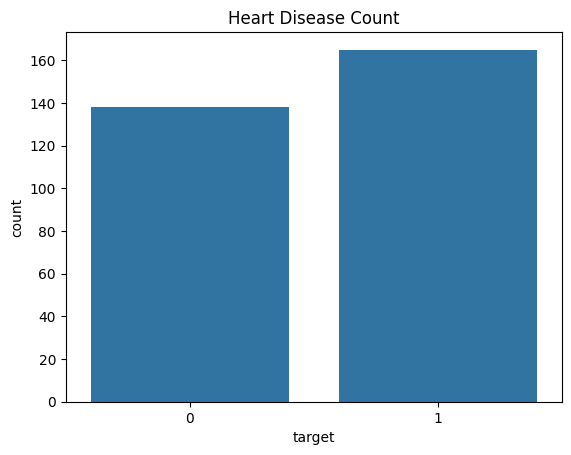

In [6]:
# Count plot for target variable
sns.countplot(x='target', data=df)

# Add title
plt.title('Heart Disease Count')

# Show graph
plt.show()

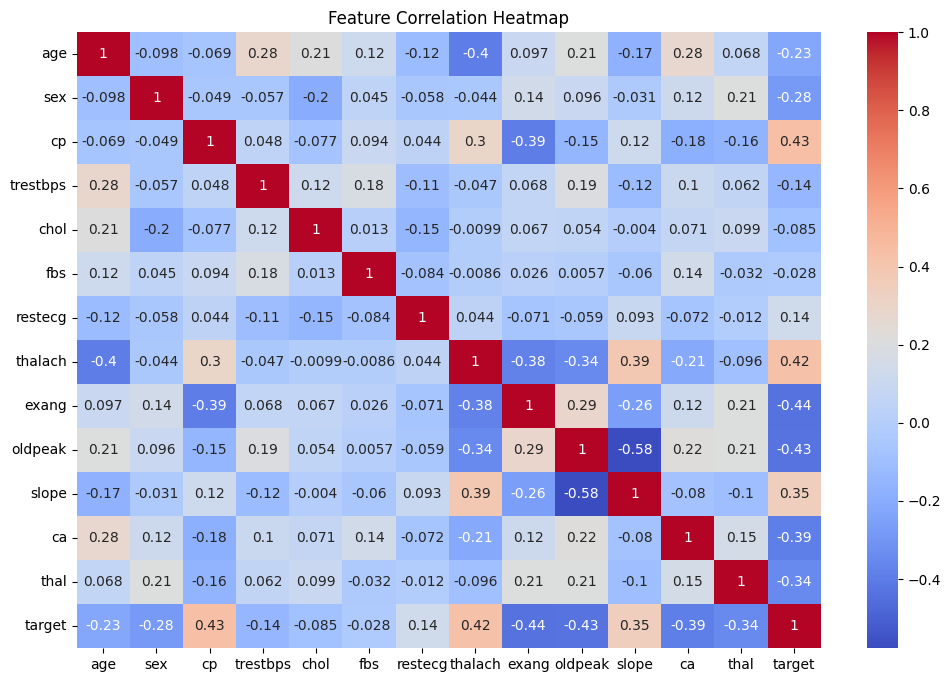

In [7]:
# Set graph size
plt.figure(figsize=(12, 8))

# Create heatmap to show relationship between features
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

# Add title
plt.title('Feature Correlation Heatmap')

# Show graph
plt.show()

In [8]:
# Select all columns except target as input features
X = df.drop('target', axis=1)

# Select target column as output
y = df['target']

In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model using training data
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [11]:
# Predict results using testing data
y_pred = model.predict(X_test)

# Display predicted values
print(y_pred)

[0 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0]


In [12]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print("Accuracy:", accuracy)

Accuracy: 0.8688524590163934


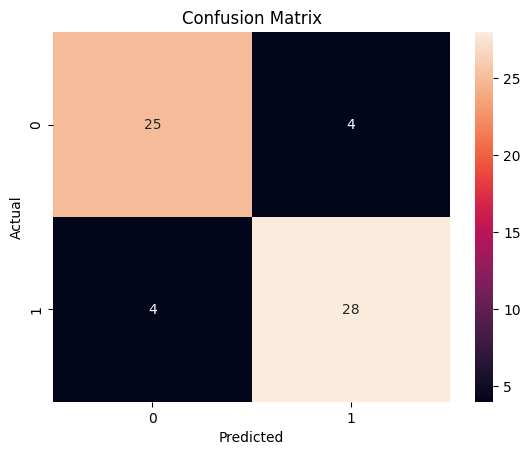

In [13]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix using heatmap
sns.heatmap(cm, annot=True, fmt='d')

# Add title and labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show graph
plt.show()

In [14]:
# Print precision, recall, and F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



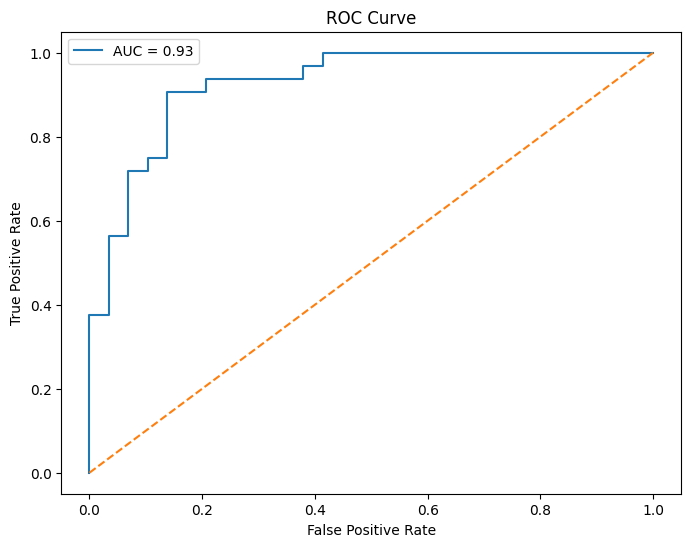

In [15]:
# Get prediction probabilities for class 1
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate ROC-AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Set graph size
plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC Curve')

# Plot diagonal line
plt.plot([0, 1], [0, 1], linestyle='--')

# Add title and labels
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Show AUC score in legend
plt.legend(['AUC = ' + str(round(auc_score, 2))])

# Show graph
plt.show()

# Conclusion

In this task, I built a heart disease prediction model using Logistic Regression. The dataset was cleaned and analyzed using exploratory data analysis. The model was evaluated using accuracy, confusion matrix, classification report, and ROC curve. The results show how machine learning can help predict heart disease risk based on patient health features.